In [ ]:
%matplotlib inline
# -*- coding: utf-8 -*-
import simplejson, sys, datetime
sys.path.append("..")
sys.path.append("../trafficintelligence")
import moving, utils # from Traffic Intelligence https://bitbucket.org/Nicolas/trafficintelligence
from pyproj import Proj

import matplotlib.pyplot as plt
import matplotlib.mlab as pylab
import numpy as np
import pandas as pd

english2French = {'Commute': 'Domicile-travail',
                  'Errand': 'Courses',
                  'Exercise': 'Sport',
                  'Leisure': 'Loisirs',
                  'Other': 'Autre',
                  'Autres': 'Autre',
                  'Autres motifs': 'Autre',
                  'School': u'École',
                  'Shopping': 'Magasinage',
                  'Work-Related': 'Travail',
                  'Work-related': 'Travail',
                  'Other': 'Autre',
                  'other': 'Autre'}

odMotifs = ['Magasinage', 'Retour au domicile', "Chercher quelqu'un",
            'Travail ', '\xc9tude / \xc9cole', 'Autre', 'Loisir',
            "Visites d'ami(e)s et/ou de la parent\xe9", "Reconduire quelqu'un",
            "Rendez-vous d'affaires", 'Sant\xe9',
            'Ind\xe9termin\xe9 / refus / NSP']

def convertJsonToMTM(data = None, filename = None):
    'Converts the input json data to MTM and optionally saves to file'
    proj = Proj(init="epsg:2950")
    if data is None:
        data = simplejson.load(open(filename))
    for i in xrange(len(data['features'])):
        latlon = data['features'][i]['geometry']['coordinates']
        mtm = [proj(p[0], p[1]) for p in latlon]
        data['features'][i]['geometry']['coordinates'] = mtm
    if filename is not None:
        simplejson.dump(data, open(utils.removeExtension(filename)+'-mtm.json', 'w'))
    return data

def convertToObjects(data, timeStep = 1, project = True, minLength = 10):
    'Converts the trips to the moving.MovingObject class from Traffic Intelligence'
    if project:
        proj = Proj(init="epsg:2950")
    objects = []
    nTrips = len(data['features'])
    for i in xrange(nTrips):
        latlon = data['features'][i]['geometry']['coordinates']
        if project:
            projectedX = [proj(p[0], p[1]) for p in latlon[::timeStep]]
        else:
            projectedX = latlon[::timeStep]
        o = moving.MovingObject(num = i, positions = moving.Trajectory(np.array(projectedX).T.tolist()))
        o.properties = data['features'][i]['properties']
        o.motif = english2French.get(o.properties['purpose'], o.properties['purpose'])
        try:
            o.start = datetime.datetime.strptime(o.properties['start'], '%Y-%m-%d %H:%M:%S')
            o.stop = datetime.datetime.strptime(o.properties['stop'], '%Y-%m-%d %H:%M:%S')
            if o.positions.length() > minLength:
                objects.append(o)
        except TypeError:
            print('{} {}'.format(o.properties['start'], o.properties['stop']))
            print('issue with {}'.format(o.properties))
            #o.start = datetime.datetime(1979, 7, 21)
            #o.stop = o.start
            #print(e)
    return objects

def printMRV(objects, motifs, color, linewidth, alpha, blackBG = False):
    fig = plt.figure()
    for o in objects:
        if o.motif in motifs:
            o.plot(color, linewidth = linewidth, alpha = alpha)
    plt.axis('equal')
    plt.axis('off')
    plt.tight_layout()
    if blackBG:
        fig.patch.set_facecolor('black')
        plt.savefig(u'mrv-'+u'-'.join(motifs).replace(' ', '-')+'-'+color+'-blackbg.png', dpi = 300, facecolor=fig.get_facecolor(), edgecolor='none')
    else:
        plt.savefig(u'mrv-'+u'-'.join(motifs).replace(' ', '-')+'-'+color+u'.png', dpi = 300)

In [2]:
import pandas as pd

df = pd.read_csv(
    "trajectories-0400-0415.txt",
    sep=r"\s+",
    header=None
)

print(df.head())

   0   1    2              3       4       5            6            7     8   \
0   1  12  884  1113433136100  16.884  48.213  6042842.116  2133117.662  14.3   
1   1  13  884  1113433136200  16.938  49.463  6042842.012  2133118.909  14.3   
2   1  14  884  1113433136300  16.991  50.712  6042841.908  2133120.155  14.3   
3   1  15  884  1113433136400  17.045  51.963  6042841.805  2133121.402  14.3   
4   1  16  884  1113433136500  17.098  53.213  6042841.701  2133122.649  14.3   

    9   10    11   12  13  14  15   16   17  
0  6.4   2  12.5  0.0   2   0   0  0.0  0.0  
1  6.4   2  12.5  0.0   2   0   0  0.0  0.0  
2  6.4   2  12.5  0.0   2   0   0  0.0  0.0  
3  6.4   2  12.5  0.0   2   0   0  0.0  0.0  
4  6.4   2  12.5  0.0   2   0   0  0.0  0.0  


   object_id  frame  category      timestamp       x       y       proj_x  \
0          1     12       884  1113433136100  16.884  48.213  6042842.116   
1          1     13       884  1113433136200  16.938  49.463  6042842.012   
2          1     14       884  1113433136300  16.991  50.712  6042841.908   
3          1     15       884  1113433136400  17.045  51.963  6042841.805   
4          1     16       884  1113433136500  17.098  53.213  6042841.701   

        proj_y  speed  acceleration  lane  length  heading  class  flag1  \
0  2133117.662   14.3           6.4     2    12.5      0.0      2      0   
1  2133118.909   14.3           6.4     2    12.5      0.0      2      0   
2  2133120.155   14.3           6.4     2    12.5      0.0      2      0   
3  2133121.402   14.3           6.4     2    12.5      0.0      2      0   
4  2133122.649   14.3           6.4     2    12.5      0.0      2      0   

   flag2  uncertainty1  uncertainty2  
0      0           0.0           0.0  
1 

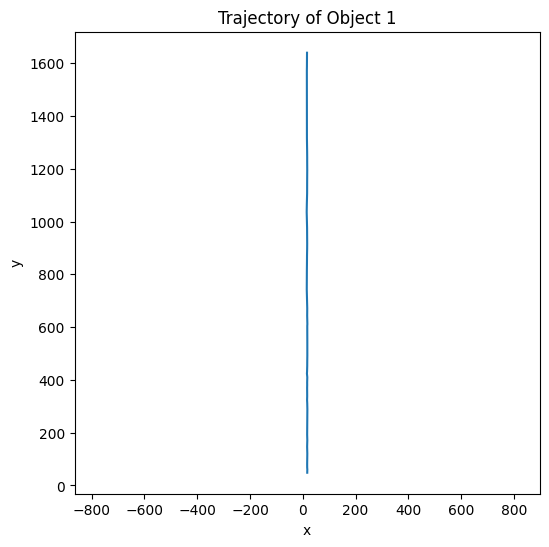

In [3]:
df.columns = [
    "object_id",
    "frame",
    "category",
    "timestamp",
    "x",
    "y",
    "proj_x",
    "proj_y",
    "speed",
    "acceleration",
    "lane",
    "length",
    "heading",
    "class",
    "flag1",
    "flag2",
    "uncertainty1",
    "uncertainty2"
]

print(df.head())

import matplotlib.pyplot as plt

first_obj = df[df["object_id"] == 1]

plt.figure(figsize=(6,6))
plt.plot(first_obj["x"], first_obj["y"])
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectory of Object 1")
plt.axis("equal")
plt.show()

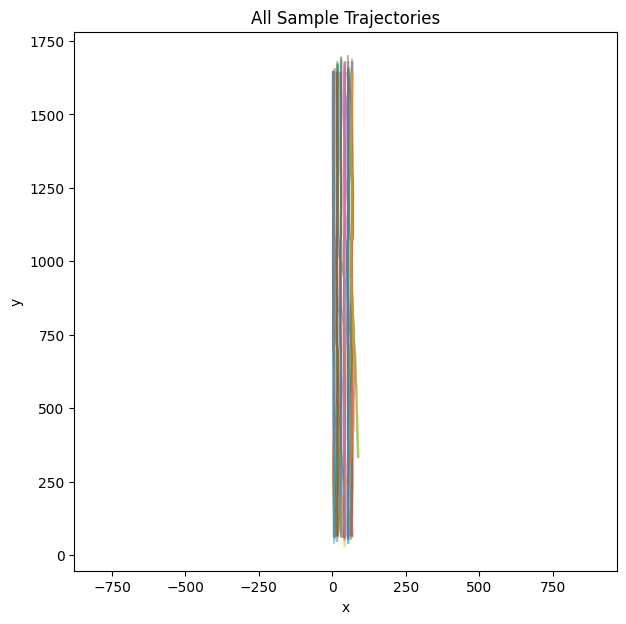

In [4]:
plt.figure(figsize=(7, 7))

for obj_id, group in df.groupby("object_id"):
    plt.plot(group["x"], group["y"], alpha=0.5)

plt.xlabel("x")
plt.ylabel("y")
plt.title("All Sample Trajectories")
plt.axis("equal")
plt.show()

In [5]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/Users/isaac/Desktop/POLY/code/traffic-intelligence/samples/test_dltrack.sqlite")

positions = pd.read_sql_query(
    "SELECT * FROM positions",
    conn
)

print(positions.head())

   trajectory_id  frame_number  x_coordinate  y_coordinate
0              1             0    668.392761   1345.091553
1              1             1    657.594925   1347.061686
2              1             2    645.096976   1348.647998
3              1             3    631.189237   1351.025940
4              1             4    619.250137   1352.353455


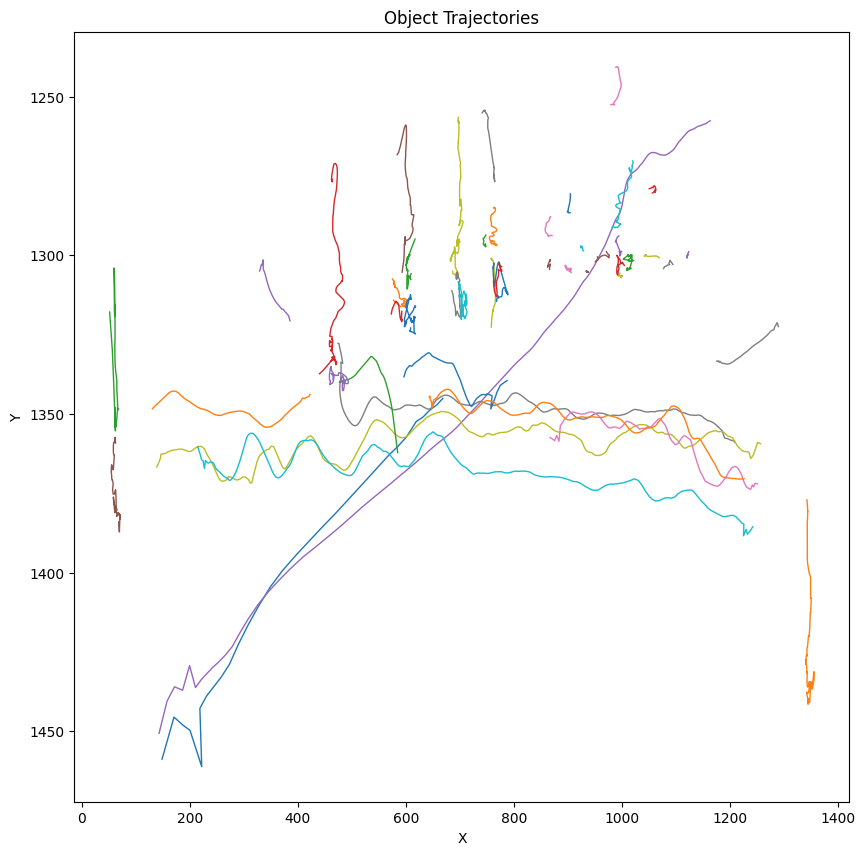

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

# 按 trajectory 分组
for tid, group in positions.groupby("trajectory_id"):

    # 按 frame 排序（很重要）
    group = group.sort_values("frame_number")

    # 画轨迹线
    plt.plot(
        group["x_coordinate"],
        group["y_coordinate"],
        linewidth=1
    )

# 图像坐标系通常 y 轴反过来更符合视频
plt.gca().invert_yaxis()

plt.title("Object Trajectories")
plt.xlabel("X")
plt.ylabel("Y")

plt.show()